# Guia practica GISTEMP: comparacion 1200 km vs 250 km

Este cuaderno centraliza la comparacion entre:
- `gistemp1200_GHCNv4_ERSSTv5.nc` (Land-Ocean Temperature Index, 1200 km smoothing)
- `gistemp250_GHCNv4.nc` (Surface air temperature, 250 km smoothing)

Analiza tres escalas espaciales:
- promedio global ponderado,
- estructura zonal tiempo-latitud,
- promedio regional para un dominio cercano a Medellin (0-10 N, 80-70 W).

Ademas reporta estadisticas de variabilidad (amplitud y varianza) y la serie diferencia `250 - 1200`.


In [1]:
import gzip
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

In [2]:
# Rutas de los datasets
PATH_1200_NC = Path('/home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp1200_GHCNv4_ERSSTv5.nc')
PATH_1200_GZ = Path('/home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp1200_GHCNv4_ERSSTv5.nc.gz')

PATH_250_NC = Path('/home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp250_GHCNv4.nc')
PATH_250_GZ = Path('/home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp250_GHCNv4.nc.gz')


def ensure_nc(nc_path, gz_path):
    if nc_path.exists():
        return nc_path
    if gz_path.exists():
        with gzip.open(gz_path, 'rb') as src, open(nc_path, 'wb') as dst:
            shutil.copyfileobj(src, dst)
        return nc_path
    raise FileNotFoundError(f'No existe ni {nc_path} ni {gz_path}')

path_1200 = ensure_nc(PATH_1200_NC, PATH_1200_GZ)
path_250 = ensure_nc(PATH_250_NC, PATH_250_GZ)

print('Producto 1200 km:', path_1200)
print('Producto 250 km :', path_250)

Producto 1200 km: /home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp1200_GHCNv4_ERSSTv5.nc
Producto 250 km : /home/gentek-g3-esp/Documentos/modelacion ambi/Tarea1ModAmb/Tarea1/gistemp250_GHCNv4.nc


In [3]:
def open_and_standardize(path):
    ds = xr.open_dataset(path)

    if 'tempanomaly' not in ds.data_vars:
        raise KeyError(f'{path.name}: no se encontro variable tempanomaly')

    required_dims = {'time', 'lat', 'lon'}
    if not required_dims.issubset(set(ds['tempanomaly'].dims)):
        raise ValueError(f'{path.name}: tempanomaly no tiene dims esperadas')

    # Convencion de longitud 0..360
    if float(ds.lon.min()) < 0:
        ds = ds.assign_coords(lon=(ds.lon % 360)).sortby('lon')

    # Asegura latitud ascendente
    if float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby('lat')

    return ds


def global_weighted_mean(da):
    w = np.cos(np.deg2rad(da.lat))
    return da.weighted(w).mean(dim=('lat', 'lon'))


def regional_weighted_mean(da, lat_min, lat_max, lon_min, lon_max):
    da = da.sortby('lat')

    if lon_min <= lon_max:
        sub = da.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    else:
        # region cruza Greenwich en formato 0..360
        left = da.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, 360))
        right = da.sel(lat=slice(lat_min, lat_max), lon=slice(0, lon_max))
        sub = xr.concat([left, right], dim='lon')

    w = np.cos(np.deg2rad(sub.lat))
    return sub.weighted(w).mean(dim=('lat', 'lon'))


def variability_stats(series, name):
    s = pd.Series(series.values, index=pd.to_datetime(series.time.values)).dropna()
    return {
        'serie': name,
        'n': int(s.shape[0]),
        'amplitud': float(s.max() - s.min()),
        'varianza': float(s.var()),
    }


def zonal_mean_stats(da):
    z = da.mean(dim='lon')
    amplitudes = []
    variances = []
    for la in z.lat.values:
        s = pd.Series(z.sel(lat=la).values).dropna()
        if len(s) == 0:
            continue
        amplitudes.append(float(s.max() - s.min()))
        variances.append(float(s.var()))
    return {
        'amplitud_media_latitudes': float(np.mean(amplitudes)),
        'varianza_media_latitudes': float(np.mean(variances)),
        'n_latitudes_validas': int(len(amplitudes)),
    }


In [4]:
# Carga y chequeo
ds1200 = open_and_standardize(path_1200)
ds250 = open_and_standardize(path_250)

print('--- 1200 km ---')
print(ds1200)
print('\n--- 250 km ---')
print(ds250)

# Alineacion temporal por interseccion (robusto si en futuras descargas cambian)
ds1200, ds250 = xr.align(ds1200, ds250, join='inner')
print('\nPeriodo comun:', pd.to_datetime(ds1200.time.values[0]).date(), 'a', pd.to_datetime(ds1200.time.values[-1]).date())
print('Numero de meses en comun:', ds1200.sizes['time'])

--- 1200 km ---
<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1753, nv: 2, lat: 90, lon: 180)
Coordinates:
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B 1.0 3.0 5.0 7.0 ... 353.0 355.0 357.0 359.0
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 114MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2026-02-09 07:49:10 by SBBX_to_nc 2.0 - ILAND=1200,...

--- 250 km ---
<xarray.Dataset> Size: 114MB
Dimensions:      (time: 1753, nv: 2, lat: 90, lon: 180)
Coordinates:
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15
  * lat    

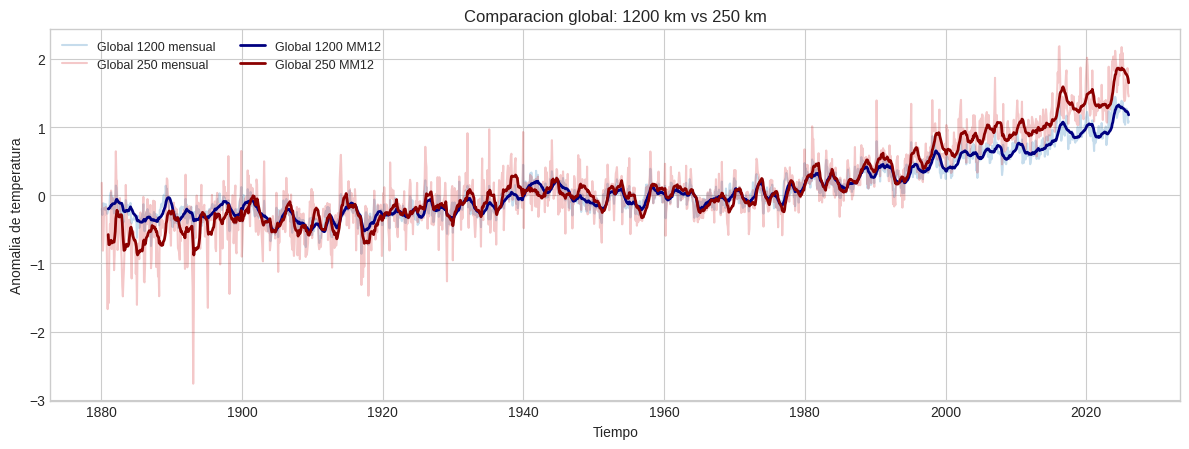

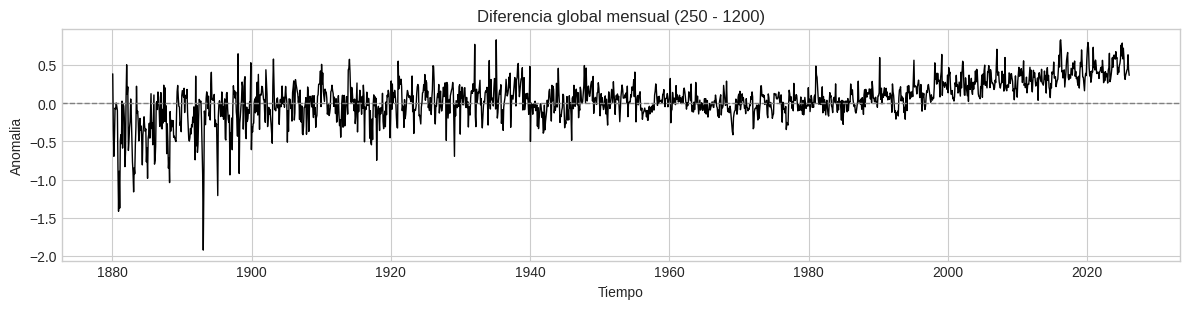

In [5]:
# 1) Promedio global ponderado + MM12
g1200 = global_weighted_mean(ds1200['tempanomaly'])
g250 = global_weighted_mean(ds250['tempanomaly'])

g1200_mm12 = g1200.rolling(time=12, min_periods=12).mean()
g250_mm12 = g250.rolling(time=12, min_periods=12).mean()

g_diff = g250 - g1200

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(g1200.time, g1200, alpha=0.25, color='tab:blue', label='Global 1200 mensual')
ax.plot(g250.time, g250, alpha=0.25, color='tab:red', label='Global 250 mensual')
ax.plot(g1200_mm12.time, g1200_mm12, linewidth=2, color='navy', label='Global 1200 MM12')
ax.plot(g250_mm12.time, g250_mm12, linewidth=2, color='darkred', label='Global 250 MM12')
ax.set_title('Comparacion global: 1200 km vs 250 km')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Anomalia de temperatura')
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(g_diff.time, g_diff, color='black', linewidth=1)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Diferencia global mensual (250 - 1200)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Anomalia')
plt.tight_layout()
plt.show()

## Resultados y discusion - Promedio global

En la figura se comparan las anomalias globales de `1200 km` (azul) y `250 km` (rojo), junto con la media movil de 12 meses.

**Observaciones esperadas en esta seccion:**
- tendencia de calentamiento sostenido desde finales del siglo XIX,
- aceleracion del calentamiento desde alrededor de 1970,
- mayor variabilidad interanual en `250 km` por menor suavizado y uso de solo estaciones terrestres.


In [6]:
# Conclusiones de la figura global (calculadas automaticamente)
def slope_per_year(da, start=None, end=None):
    s = pd.Series(da.values, index=pd.to_datetime(da.time.values)).dropna()
    if start is not None:
        s = s[s.index >= pd.Timestamp(start)]
    if end is not None:
        s = s[s.index <= pd.Timestamp(end)]
    x = (s.index.year + (s.index.month - 0.5) / 12.0).to_numpy()
    y = s.to_numpy()
    return float(np.polyfit(x, y, 1)[0]), int(len(s))

amp_g1200 = float(pd.Series(g1200.values).dropna().max() - pd.Series(g1200.values).dropna().min())
var_g1200 = float(pd.Series(g1200.values).dropna().var())
amp_g250 = float(pd.Series(g250.values).dropna().max() - pd.Series(g250.values).dropna().min())
var_g250 = float(pd.Series(g250.values).dropna().var())

m1200_pre, _ = slope_per_year(g1200, '1880-01-01', '1969-12-31')
m1200_post, _ = slope_per_year(g1200, '1970-01-01', '2026-12-31')
m250_pre, _ = slope_per_year(g250, '1880-01-01', '1969-12-31')
m250_post, _ = slope_per_year(g250, '1970-01-01', '2026-12-31')

print('Figura global - conclusiones')
print(f'- Tendencia positiva 1200 km: {m1200_post:.4f} C/anio (1970-2026), mayor que {m1200_pre:.4f} C/anio (1880-1969).')
print(f'- Tendencia positiva 250 km:  {m250_post:.4f} C/anio (1970-2026), mayor que {m250_pre:.4f} C/anio (1880-1969).')
print(f'- Amplitud global: 1200 km = {amp_g1200:.4f} C, 250 km = {amp_g250:.4f} C.')
print(f'- Varianza global: 1200 km = {var_g1200:.4f}, 250 km = {var_g250:.4f}.')
print(f'- Verificacion de mayor variabilidad en 250 km: {var_g250 > var_g1200}.')

Figura global - conclusiones
- Tendencia positiva 1200 km: 0.0204 C/anio (1970-2026), mayor que 0.0040 C/anio (1880-1969).
- Tendencia positiva 250 km:  0.0307 C/anio (1970-2026), mayor que 0.0073 C/anio (1880-1969).
- Amplitud global: 1200 km = 2.3564 C, 250 km = 4.9503 C.
- Varianza global: 1200 km = 0.1768, 250 km = 0.3953.
- Verificacion de mayor variabilidad en 250 km: True.


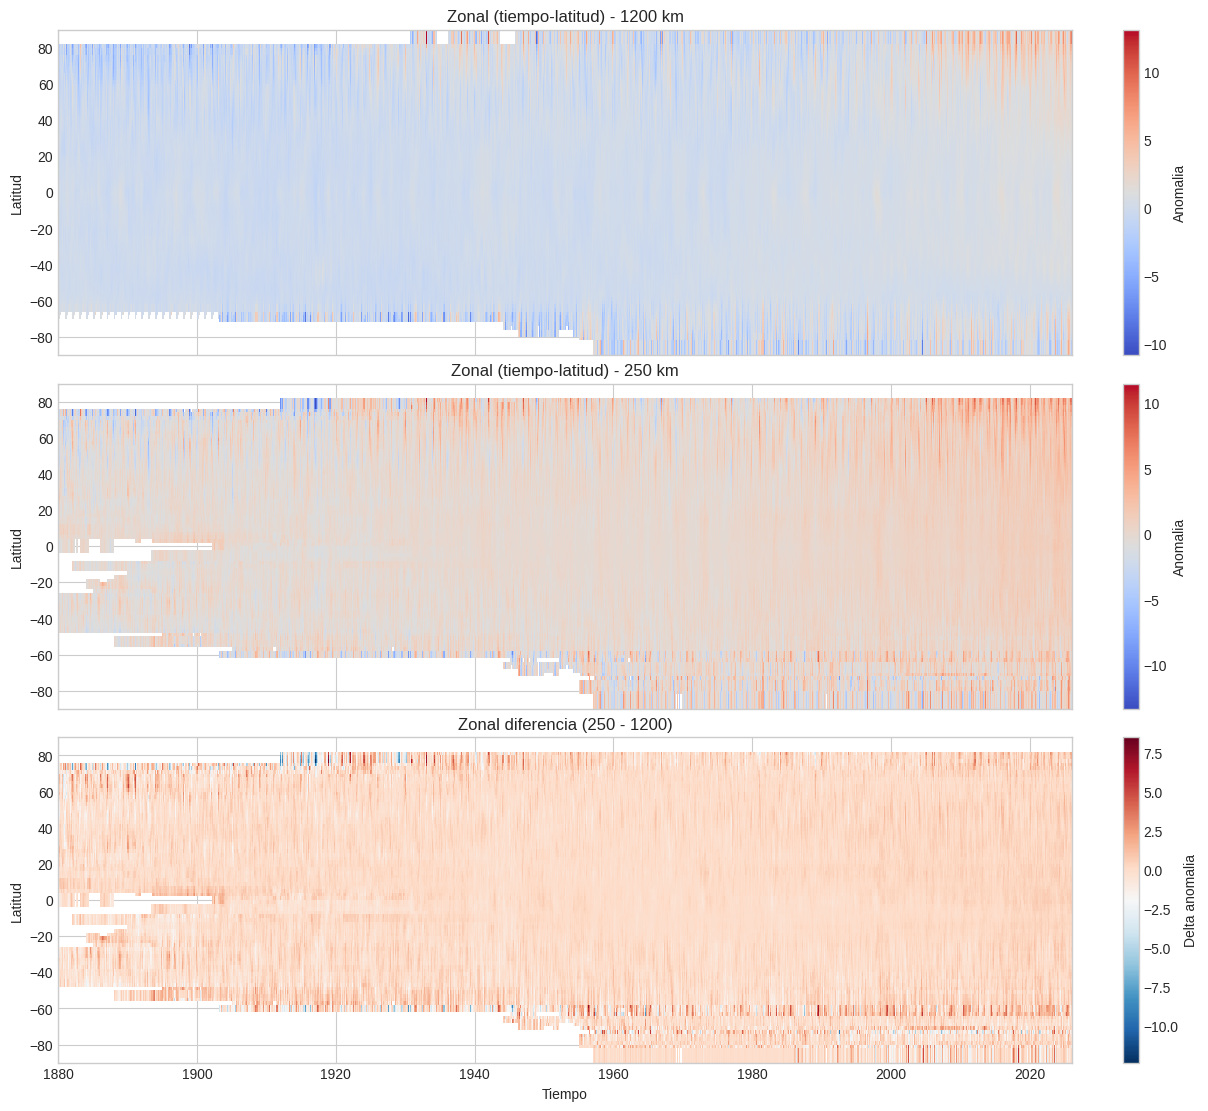

In [7]:
# 2) Analisis zonal tiempo-latitud
z1200 = ds1200['tempanomaly'].mean(dim='lon')
z250 = ds250['tempanomaly'].mean(dim='lon')
z_diff = z250 - z1200

fig, axs = plt.subplots(3, 1, figsize=(12, 11), sharex=True, constrained_layout=True)

pcm1 = axs[0].pcolormesh(z1200.time, z1200.lat, z1200.T, shading='auto', cmap='coolwarm')
axs[0].set_title('Zonal (tiempo-latitud) - 1200 km')
axs[0].set_ylabel('Latitud')
fig.colorbar(pcm1, ax=axs[0], label='Anomalia')

pcm2 = axs[1].pcolormesh(z250.time, z250.lat, z250.T, shading='auto', cmap='coolwarm')
axs[1].set_title('Zonal (tiempo-latitud) - 250 km')
axs[1].set_ylabel('Latitud')
fig.colorbar(pcm2, ax=axs[1], label='Anomalia')

pcm3 = axs[2].pcolormesh(z_diff.time, z_diff.lat, z_diff.T, shading='auto', cmap='RdBu_r')
axs[2].set_title('Zonal diferencia (250 - 1200)')
axs[2].set_xlabel('Tiempo')
axs[2].set_ylabel('Latitud')
fig.colorbar(pcm3, ax=axs[2], label='Delta anomalia')

plt.show()

## Resultados y discusion - Media zonal

Los mapas de calor muestran la evolucion temporal por latitud (promedio longitudinal por mes).

**Interpretacion esperada:**
- `1200 km` presenta patrones mas continuos por el mayor suavizado espacial,
- `250 km` resalta mayor heterogeneidad y transiciones mas abruptas,
- las metricas zonales promedio (amplitud y varianza de cada banda latitudinal) deben ser mayores en `250 km`.


In [8]:
# Conclusiones de la figura zonal (calculadas automaticamente)
zs1200 = zonal_mean_stats(ds1200['tempanomaly'])
zs250 = zonal_mean_stats(ds250['tempanomaly'])

print('Figura zonal - conclusiones')
print(f"- Amplitud media de series zonales: 1200 km = {zs1200['amplitud_media_latitudes']:.4f} C, 250 km = {zs250['amplitud_media_latitudes']:.4f} C.")
print(f"- Varianza media de series zonales: 1200 km = {zs1200['varianza_media_latitudes']:.4f}, 250 km = {zs250['varianza_media_latitudes']:.4f}.")
print(f"- Verificacion de mayor variabilidad zonal en 250 km: {zs250['varianza_media_latitudes'] > zs1200['varianza_media_latitudes']}.")
print(f"- Latitudes validas usadas: 1200 km = {zs1200['n_latitudes_validas']}, 250 km = {zs250['n_latitudes_validas']}.")

Figura zonal - conclusiones
- Amplitud media de series zonales: 1200 km = 6.7295 C, 250 km = 8.7405 C.
- Varianza media de series zonales: 1200 km = 1.1940, 250 km = 1.6601.
- Verificacion de mayor variabilidad zonal en 250 km: True.
- Latitudes validas usadas: 1200 km = 90, 250 km = 86.


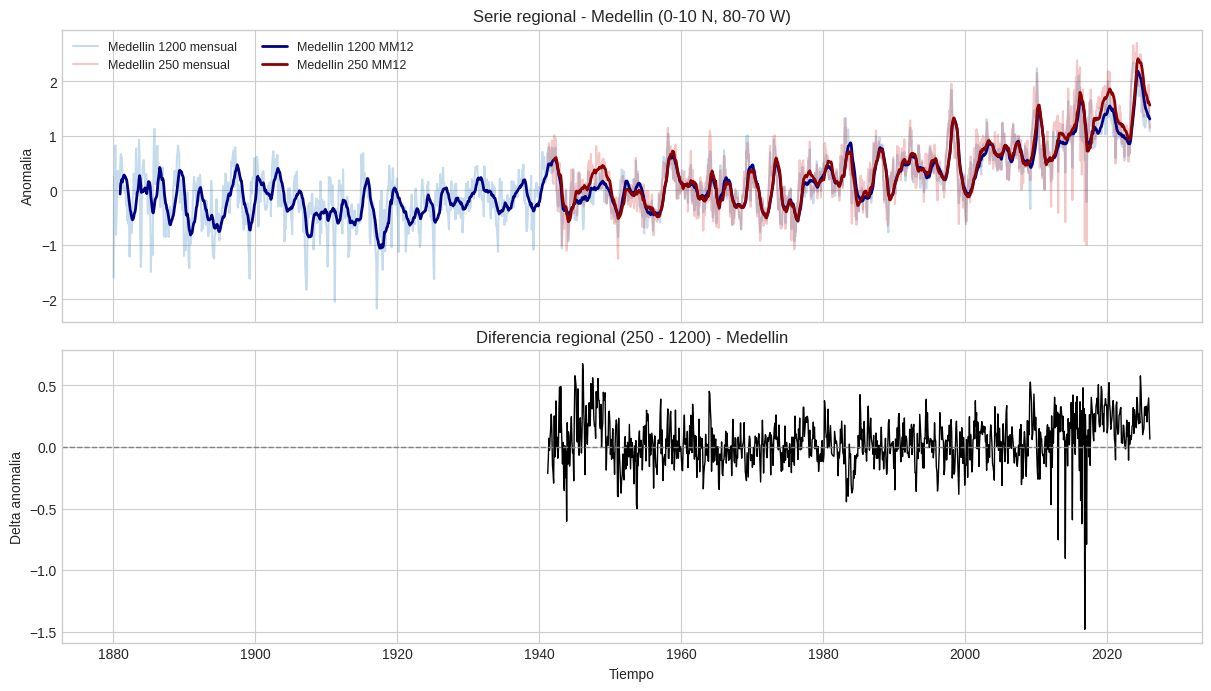

In [9]:
# 3) Analisis regional: dominio cercano a Medellin
# Region solicitada: 0-10 N, 80-70 W  -> en 0..360 equivale a 280-290
REGION_MEDELLIN = {'lat_min': 0, 'lat_max': 10, 'lon_min': 280, 'lon_max': 290}

med1200 = regional_weighted_mean(ds1200['tempanomaly'], **REGION_MEDELLIN)
med250 = regional_weighted_mean(ds250['tempanomaly'], **REGION_MEDELLIN)
med_diff = med250 - med1200

fig, axs = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True, constrained_layout=True)

axs[0].plot(med1200.time, med1200, alpha=0.25, color='tab:blue', label='Medellin 1200 mensual')
axs[0].plot(med250.time, med250, alpha=0.25, color='tab:red', label='Medellin 250 mensual')
axs[0].plot(med1200.time, med1200.rolling(time=12, min_periods=12).mean(), linewidth=2, color='navy', label='Medellin 1200 MM12')
axs[0].plot(med250.time, med250.rolling(time=12, min_periods=12).mean(), linewidth=2, color='darkred', label='Medellin 250 MM12')
axs[0].set_title('Serie regional - Medellin (0-10 N, 80-70 W)')
axs[0].set_ylabel('Anomalia')
axs[0].legend(ncols=2, fontsize=9)

axs[1].plot(med_diff.time, med_diff, color='black', linewidth=1)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1].set_title('Diferencia regional (250 - 1200) - Medellin')
axs[1].set_ylabel('Delta anomalia')
axs[1].set_xlabel('Tiempo')

plt.show()

## Resultados y discusion - Promedio regional (Medellin)

La serie regional se calcula en `0-10 N, 80-70 W` (incluye zona andina y parte del Caribe).

**Puntos clave esperados:**
- `1200 km` integra celdas tierra-oceano (serie mas completa),
- `250 km` usa solo estaciones terrestres (aparecen huecos),
- en esta region especifica, la amplitud de `250 km` puede ser menor, pero su varianza puede ser mayor.


In [10]:
# Conclusiones de la figura regional (calculadas automaticamente)
med_s1200 = pd.Series(med1200.values).dropna()
med_s250 = pd.Series(med250.values).dropna()

amp_med1200 = float(med_s1200.max() - med_s1200.min())
var_med1200 = float(med_s1200.var())
amp_med250 = float(med_s250.max() - med_s250.min())
var_med250 = float(med_s250.var())
missing_med250 = int(ds250.sizes['time'] - med_s250.shape[0])

print('Figura regional Medellin - conclusiones')
print(f'- Amplitud regional: 1200 km = {amp_med1200:.4f} C, 250 km = {amp_med250:.4f} C.')
print(f'- Varianza regional: 1200 km = {var_med1200:.4f}, 250 km = {var_med250:.4f}.')
print(f'- Verificacion (amplitud 250 < 1200): {amp_med250 < amp_med1200}.')
print(f'- Verificacion (varianza 250 > 1200): {var_med250 > var_med1200}.')
print(f'- Meses faltantes en 250 km dentro de la region: {missing_med250}.')

Figura regional Medellin - conclusiones
- Amplitud regional: 1200 km = 4.5094 C, 250 km = 3.9596 C.
- Varianza regional: 1200 km = 0.3935, 250 km = 0.4622.
- Verificacion (amplitud 250 < 1200): True.
- Verificacion (varianza 250 > 1200): True.
- Meses faltantes en 250 km dentro de la region: 734.


In [11]:
# 4) Estadisticas de variabilidad comparadas (Tabla 1)
zs1200 = zonal_mean_stats(ds1200['tempanomaly'])
zs250 = zonal_mean_stats(ds250['tempanomaly'])

tabla1 = pd.DataFrame([
    {
        'Escala y resolucion': 'Promedio global, 1200 km',
        'Amplitud total (C)': float(pd.Series(g1200.values).dropna().max() - pd.Series(g1200.values).dropna().min()),
        'Varianza temporal': float(pd.Series(g1200.values).dropna().var()),
    },
    {
        'Escala y resolucion': 'Promedio global, 250 km',
        'Amplitud total (C)': float(pd.Series(g250.values).dropna().max() - pd.Series(g250.values).dropna().min()),
        'Varianza temporal': float(pd.Series(g250.values).dropna().var()),
    },
    {
        'Escala y resolucion': 'Media zonal (promedio de latitudes), 1200 km',
        'Amplitud total (C)': zs1200['amplitud_media_latitudes'],
        'Varianza temporal': zs1200['varianza_media_latitudes'],
    },
    {
        'Escala y resolucion': 'Media zonal (promedio de latitudes), 250 km',
        'Amplitud total (C)': zs250['amplitud_media_latitudes'],
        'Varianza temporal': zs250['varianza_media_latitudes'],
    },
    {
        'Escala y resolucion': 'Promedio regional (0-10 N, 80-70 W), 1200 km',
        'Amplitud total (C)': float(pd.Series(med1200.values).dropna().max() - pd.Series(med1200.values).dropna().min()),
        'Varianza temporal': float(pd.Series(med1200.values).dropna().var()),
    },
    {
        'Escala y resolucion': 'Promedio regional (0-10 N, 80-70 W), 250 km',
        'Amplitud total (C)': float(pd.Series(med250.values).dropna().max() - pd.Series(med250.values).dropna().min()),
        'Varianza temporal': float(pd.Series(med250.values).dropna().var()),
    },
])

tabla1

,Escala y resolucion,Amplitud total (C),Varianza temporal
0,"Promedio global, 1200 km",2.3564,0.1768
1,"Promedio global, 250 km",4.9503,0.3953
2,"Media zonal (promedio de latitudes), 1200 km",6.7295,1.1940
3,"Media zonal (promedio de latitudes), 250 km",8.7405,1.6601
4,"Promedio regional (0-10 N, 80-70 W), 1200 km",4.5094,0.3935
5,"Promedio regional (0-10 N, 80-70 W), 250 km",3.9596,0.4622


## Tabla 1. Resumen de magnitud y variabilidad

La tabla resume amplitud total y varianza temporal para las tres escalas (global, zonal y regional) en ambas resoluciones.


In [12]:
# Comentario final de tabla (verificacion automatica)
row = {r['Escala y resolucion']: r for r in tabla1.to_dict(orient='records')}

print('Conclusiones de la Tabla 1')
print('- La varianza global aumenta al pasar de 1200 km a 250 km:', row['Promedio global, 250 km']['Varianza temporal'] > row['Promedio global, 1200 km']['Varianza temporal'])
print('- La varianza zonal media aumenta al pasar de 1200 km a 250 km:', row['Media zonal (promedio de latitudes), 250 km']['Varianza temporal'] > row['Media zonal (promedio de latitudes), 1200 km']['Varianza temporal'])
print('- En la region Medellin, la amplitud es ligeramente menor en 250 km:', row['Promedio regional (0-10 N, 80-70 W), 250 km']['Amplitud total (C)'] < row['Promedio regional (0-10 N, 80-70 W), 1200 km']['Amplitud total (C)'])
print('- En la region Medellin, la varianza es mayor en 250 km:', row['Promedio regional (0-10 N, 80-70 W), 250 km']['Varianza temporal'] > row['Promedio regional (0-10 N, 80-70 W), 1200 km']['Varianza temporal'])

Conclusiones de la Tabla 1
- La varianza global aumenta al pasar de 1200 km a 250 km: True
- La varianza zonal media aumenta al pasar de 1200 km a 250 km: True
- En la region Medellin, la amplitud es ligeramente menor en 250 km: True
- En la region Medellin, la varianza es mayor en 250 km: True


In [13]:
# 5) Metricas resumen de diferencia 250 - 1200
resumen_diff = pd.DataFrame([
    {
        'serie_diff': 'Global (250-1200)',
        'media': float(pd.Series(g_diff.values).dropna().mean()),
        'std': float(pd.Series(g_diff.values).dropna().std()),
        'max_abs': float(pd.Series(g_diff.values).dropna().abs().max()),
    },
    {
        'serie_diff': 'Medellin (250-1200)',
        'media': float(pd.Series(med_diff.values).dropna().mean()),
        'std': float(pd.Series(med_diff.values).dropna().std()),
        'max_abs': float(pd.Series(med_diff.values).dropna().abs().max()),
    },
])
resumen_diff

,serie_diff,media,std,max_abs
0,Global (250-1200),0.0475,0.2688,1.9233
1,Medellin (250-1200),0.0448,0.1964,1.4795


## Resultados y discusion (texto consolidado)

### Promedio global

En la figura global se comparan las anomalias de temperatura de `1200 km` (azul) y `250 km` (rojo), junto con media movil de 12 meses.

- Ambas series muestran calentamiento sostenido desde finales del siglo XIX.
- El incremento se acelera desde alrededor de 1970 (ver pendientes calculadas en la seccion de conclusiones globales).
- El producto `250 km` presenta mayor variabilidad interanual: amplitud y varianza globales mayores que en `1200 km`.

### Media zonal

Los mapas tiempo-latitud muestran diferencias en suavizado espacial.

- `1200 km` presenta transiciones latitudinales mas continuas.
- `250 km` muestra mayor heterogeneidad espacial y temporal por menor radio de interpolacion.
- Las metricas zonales promedio confirman mayor variabilidad en `250 km`.

### Promedio regional (0-10 N, 80-70 W)

Para el dominio cercano a Medellin, el contraste entre productos muestra que:

- `1200 km` mantiene serie completa al combinar tierra-oceano.
- `250 km` (solo terrestre) presenta faltantes dentro del dominio.
- En esta region, la amplitud de `250 km` es ligeramente menor, pero su varianza es mayor, consistente con mayor ruido local y cobertura incompleta sobre oceano.

### Tabla 1

La tabla confirma que al reducir el radio de interpolacion a `250 km` aumenta la varianza en escalas global y zonal, y tambien en la escala regional evaluada. Esto evidencia que la resolucion espacial afecta la magnitud de la variabilidad y la interpretacion de tendencias.
